In [5]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Import and load the dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# check the data
df.info()
print(df.isna().sum().sum(),"missing values")
print(df.duplicated().sum(),"duplicate rows")


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
# finding the problem in TotalCharges
print((df["TotalCharges"].str.strip() == "").sum(),"empty values in TotalCharges")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[df["TotalCharges"].isna()][["tenure","MonthlyCharges","TotalCharges"]]


11 empty values in TotalCharges


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [9]:
# clean the data
df["TotalCharges"] = df["TotalCharges"].fillna(0)                 # new customers → 0 charges
df = df.drop(columns="customerID")                                # ID is useless for prediction
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})                # target → 1/0
df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Yes", 0: "No"})  # match other Yes/No columns
df.dtypes

gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

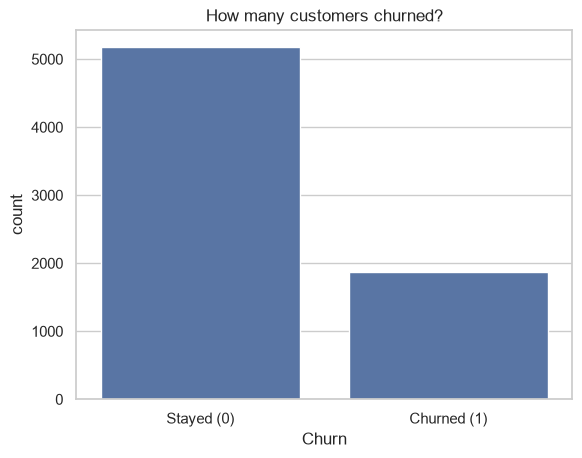

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [10]:
# class balance
ax = sns.countplot(x="Churn", data=df)
ax.set_xticks([0, 1], ["Stayed (0)", "Churned (1)"])
ax.set_title("How many customers churned?")
plt.savefig("figures/01_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()
df["Churn"].value_counts(normalize=True)

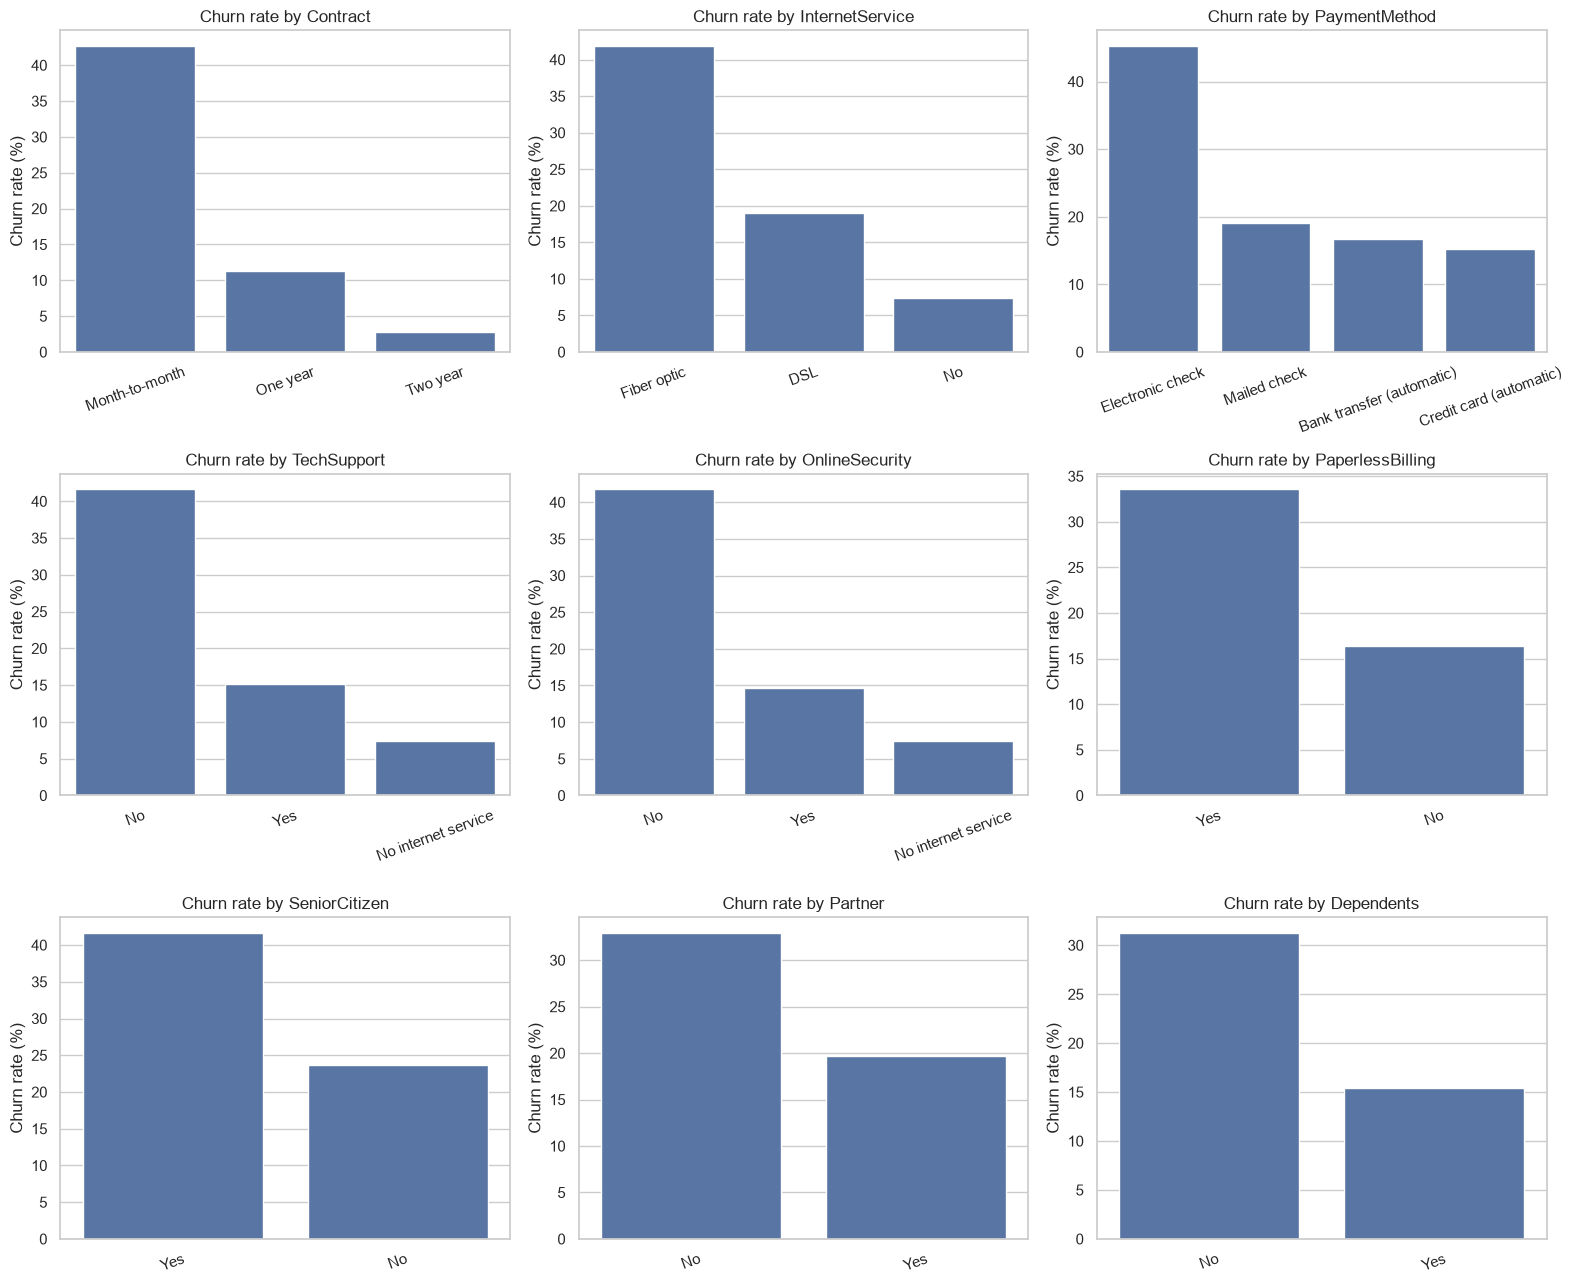

In [11]:
# churn rate by customer type
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "OnlineSecurity", "PaperlessBilling",
            "SeniorCitizen", "Partner", "Dependents"]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("figures/02_churn_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

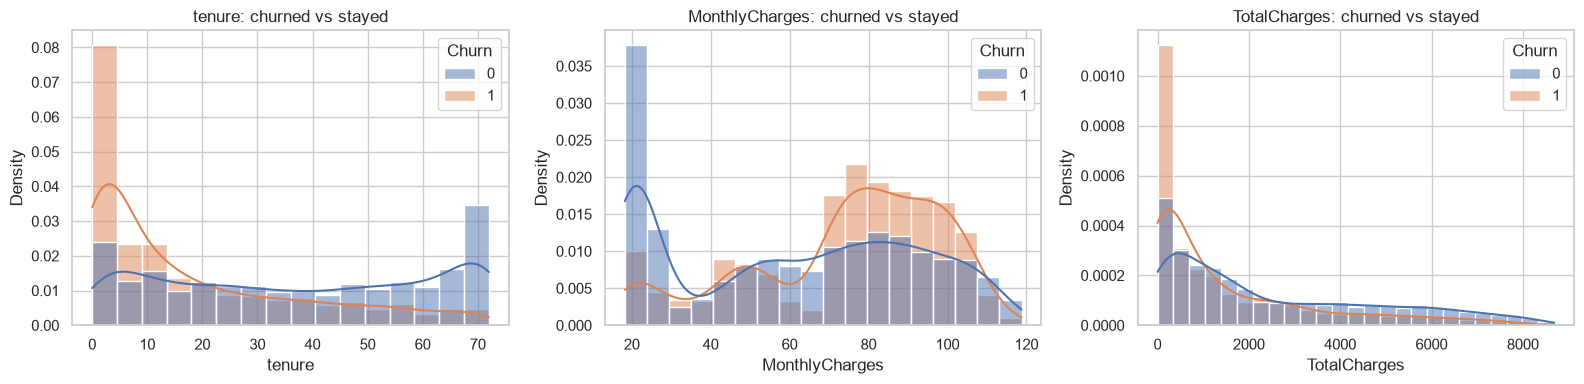

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550


In [12]:
# tenure and charges, churned vs stayed
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True,
                 stat="density", common_norm=False, ax=ax)
    ax.set_title(f"{col}: churned vs stayed")
plt.tight_layout()
plt.savefig("figures/03_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
df.groupby("Churn")[num_cols].median()

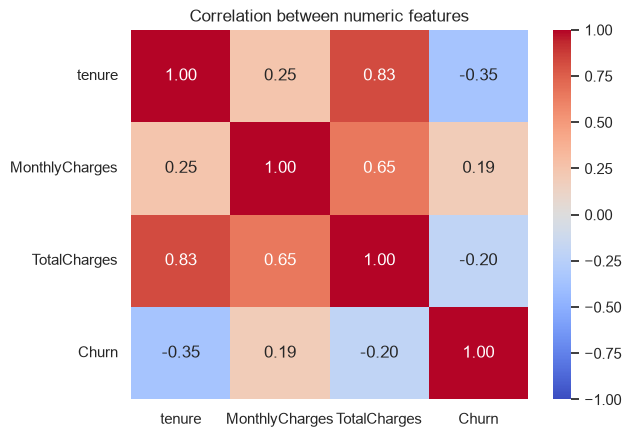

In [13]:
# correlation heatmap
corr = df[num_cols + ["Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.savefig("figures/04_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# split into train and test sets
from sklearn.model_selection import train_test_split

X = df.drop(columns="Churn")   
y = df["Churn"]                

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5634, 19)  Test: (1409, 19)


In [ ]:
# preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                         
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),   
])

In [ ]:
# A helper function that scores each model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

results = []

def evaluate(name, setting, model):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    row = {"Model": name, "Setting": setting,
           "Accuracy": accuracy_score(y_test, pred),
           "Precision": precision_score(y_test, pred),
           "Recall": recall_score(y_test, pred),
           "F1": f1_score(y_test, pred),
           "ROC-AUC": roc_auc_score(y_test, prob)}
    results.append(row)
    return row


In [17]:
# Experiment1, deafault settings, no preprocessing
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

default_models = {
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
}

for name, clf in default_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)                  # ← this is the "training"
    print(evaluate(name, "Default", pipe))

{'Model': 'KNN', 'Setting': 'Default', 'Accuracy': 0.7572746628814763, 'Precision': 0.5418848167539267, 'Recall': 0.553475935828877, 'F1': 0.5476190476190477, 'ROC-AUC': 0.788166834586272}
{'Model': 'Logistic Regression', 'Setting': 'Default', 'Accuracy': 0.8055358410220014, 'Precision': 0.6572327044025157, 'Recall': 0.5588235294117647, 'F1': 0.6040462427745664, 'ROC-AUC': 0.8420341522643313}
{'Model': 'Random Forest', 'Setting': 'Default', 'Accuracy': 0.7821149751596878, 'Precision': 0.6127946127946128, 'Recall': 0.48663101604278075, 'F1': 0.5424739195230999, 'ROC-AUC': 0.8182528610917357}


In [18]:
# Experiment 2, hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_spaces = {
    "KNN": (KNeighborsClassifier(), {
        "model__n_neighbors": list(range(3, 52, 2)),
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"],
    }),
    "Logistic Regression": (LogisticRegression(solver="liblinear", max_iter=1000), {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0, 1],            # 0 = L2 (ridge), 1 = L1 (lasso)
        "model__class_weight": [None, "balanced"],
    }),
    "Random Forest": (RandomForestClassifier(random_state=42), {
        "model__n_estimators": [100, 300],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"],
    }),
}

best_models = {}
for name, (clf, grid) in search_spaces.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=-1)
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    print(f"\n{name} best params: {search.best_params_}")
    print(f"{name} best CV F1: {search.best_score_:.3f}")
    print(evaluate(name, "Tuned", search.best_estimator_))


KNN best params: {'model__metric': 'euclidean', 'model__n_neighbors': 47, 'model__weights': 'uniform'}
KNN best CV F1: 0.610
{'Model': 'KNN', 'Setting': 'Tuned', 'Accuracy': 0.7828246983676366, 'Precision': 0.5913978494623656, 'Recall': 0.5882352941176471, 'F1': 0.5898123324396782, 'ROC-AUC': 0.8319421839882197}

Logistic Regression best params: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': 0}
Logistic Regression best CV F1: 0.629
{'Model': 'Logistic Regression', 'Setting': 'Tuned', 'Accuracy': 0.7409510290986515, 'Precision': 0.5077720207253886, 'Recall': 0.786096256684492, 'F1': 0.6169989506820567, 'ROC-AUC': 0.840982717197551}

Random Forest best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}
Random Forest best CV F1: 0.634
{'Model': 'Random Forest', 'Setting': 'Tuned', 'Accuracy': 0.7544357700496807, 'Precision': 0.524822695035461, 'Recall': 0.7914438502673797, 'F1': 0.63113

In [19]:
# Comparison Table
results_df = pd.DataFrame(results).round(3)
results_df.to_csv("figures/results_table.csv", index=False)
results_df

,Model,Setting,Accuracy,Precision,Recall,F1,ROC-AUC
0,KNN,Default,0.757,0.542,0.553,0.548,0.788
1,Logistic Regression,Default,0.806,0.657,0.559,0.604,0.842
2,Random Forest,Default,0.782,0.613,0.487,0.542,0.818
3,KNN,Tuned,0.783,0.591,0.588,0.590,0.832
4,Logistic Regression,Tuned,0.741,0.508,0.786,0.617,0.841
5,Random Forest,Tuned,0.754,0.525,0.791,0.631,0.844


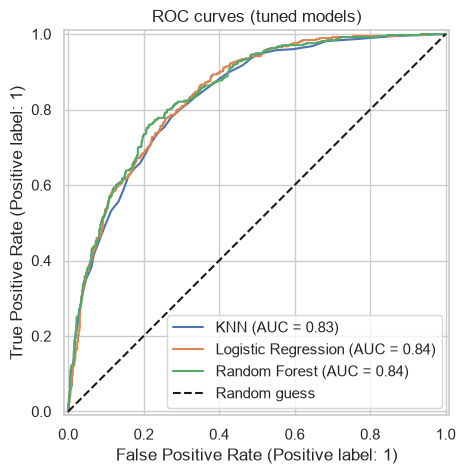

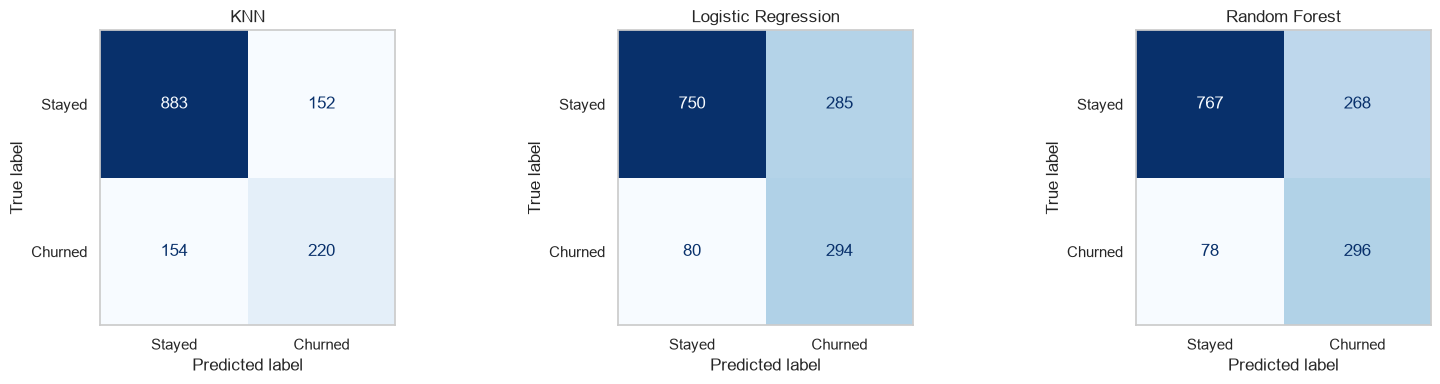

In [20]:
# ROC curves and confusion matrices
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_title("ROC curves (tuned models)")
ax.legend()
plt.savefig("figures/05_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, model) in zip(axes, best_models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap="Blues",
                                          display_labels=["Stayed", "Churned"], colorbar=False)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.savefig("figures/06_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

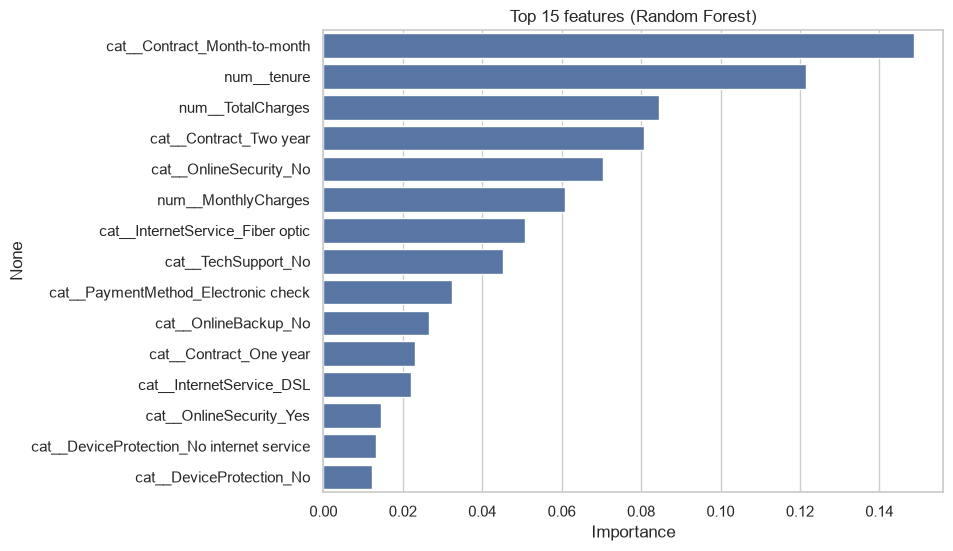

In [21]:
# which feature matter most?
rf = best_models["Random Forest"]
feature_names = rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf.named_steps["model"].feature_importances_, index=feature_names)
top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 15 features (Random Forest)")
plt.xlabel("Importance")
plt.savefig("figures/07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Does the model treat groups fairly?
from sklearn.metrics import recall_score, precision_score

best = best_models["Random Forest"]
check = X_test.copy()
check["actual"] = y_test
check["predicted"] = best.predict(X_test)

def fairness_report(col):
    rows = []
    for group, g in check.groupby(col):
        rows.append({
            col: group,
            "Customers": len(g),
            "Actual churn %": round(g["actual"].mean() * 100, 1),
            "Flagged as churn %": round(g["predicted"].mean() * 100, 1),
            "Recall": round(recall_score(g["actual"], g["predicted"]), 3),
            "Precision": round(precision_score(g["actual"], g["predicted"]), 3),
        })
    return pd.DataFrame(rows)

for col in ["gender", "SeniorCitizen"]:
    display(fairness_report(col))

,gender,Customers,Actual churn %,Flagged as churn %,Recall,Precision
0,Female,687,28.1,39.2,0.772,0.554
1,Male,722,25.1,40.9,0.812,0.498


,SeniorCitizen,Customers,Actual churn %,Flagged as churn %,Recall,Precision
0,No,1187,23.3,35.5,0.754,0.494
1,Yes,222,44.1,64.4,0.898,0.615


In [23]:
# Is gender needed at all?
from sklearn.base import clone

X_train_ng = X_train.drop(columns="gender")
X_test_ng = X_test.drop(columns="gender")

prep_ng = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), [c for c in cat_cols if c != "gender"]),
])
rf_ng = Pipeline([("prep", prep_ng), ("model", clone(best.named_steps["model"]))])
rf_ng.fit(X_train_ng, y_train)

print("With gender    F1:", round(f1_score(y_test, best.predict(X_test)), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, best.predict_proba(X_test)[:, 1]), 3))
print("Without gender F1:", round(f1_score(y_test, rf_ng.predict(X_test_ng)), 3),
      " ROC-AUC:", round(roc_auc_score(y_test, rf_ng.predict_proba(X_test_ng)[:, 1]), 3))

With gender    F1: 0.631  ROC-AUC: 0.844
Without gender F1: 0.634  ROC-AUC: 0.843
